# OVCA (crop) Dataset MLP gexp predictor

Using an MLP to predict gexp of Xenium OVCA (a crop) data from SpatialFusion generated embeddings. Following sCellST prediction architecture (3-layer MLP with 256 hidden units) 



Evaluation:
- Evaluate prediction of the three embeddings (PCC, SCC)
- Best prediction versus actually running sCellST

### Step 1: Loading the SpatialFusion embeddings

In [1]:
from spatialfusion.embed.embed import AEInputs, run_full_embedding

# Standard library
import logging
import os
import warnings
import pathlib as pl

# Third-party libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import shapely.wkb
import tifffile
import timm
import torch
from PIL import Image
from tqdm.notebook import tqdm
from torchvision import transforms

/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [ ]:
# loading adata and tiff
output_dir = '/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial'
uni_df = pd.read_parquet(pl.Path(output_dir) / 'UNI.parquet')
scgpt_df = pd.read_parquet(pl.Path(output_dir) / 'scGPT.parquet')

# importing adata for true gexp and cell labels
adata_path = "/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/data/tutadata_subset.h5ad"
adata = sc.read_h5ad(adata_path)

sample_name = "OVCA_Xenium"

# read in wsi image (for visualization later)
source_image_path = '/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/data/wsi_crop.ome.tif'
with tifffile.TiffFile(source_image_path) as tif:
    wsi = tif.series[0].asarray()


ae_inputs_by_sample = {
    sample_name: AEInputs(adata=adata, z_uni=uni_df, z_scgpt=scgpt_df),
}


In [3]:
from spatialfusion.utils.pkg_ckpt import resolve_pkg_ckpt
from spatialfusion.embed.embed import load_paired_ae, ae_from_arrays

device = "cuda" if torch.cuda.is_available() else "cpu"

# Resolve packaged pretrained checkpoints
ae_ckpt = resolve_pkg_ckpt("checkpoint_dir_ae/spatialfusion-multimodal-ae.pt")

# Infer dimensions
d1_dim, d2_dim = ae_inputs_by_sample[sample_name].z_uni.shape[1], ae_inputs_by_sample[sample_name].z_scgpt.shape[1]

# Load AE model
ae_model = load_paired_ae(ae_ckpt, d1_dim, d2_dim, latent_dim=64, device=device)

# Run AE embedding
z1_df, z2_df, z_joint_df = ae_from_arrays(
    ae_model,
    ae_inputs_by_sample[sample_name],
    device=device,
    combine_mode="average",  # or "concat", "z1", "z2",
    batch_size=None,  # optional, can be tuned based on dataset size and GPU memory, None automatically determines batch size based on input size and available memory
)

/insomnia001/depts/morpheus/users/me2982/miniconda3/envs/spatialfusion/lib/python3.10/site-packages/spatialfusion/embed/embed.py:195: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feat

### Step 2: Define Targets to predict (top 1000 HVS + marker genes)

Marker genes defined by "Identification of Specific Cell Subpopulations and Marker Genes in Ovarian Cancer Using Single-Cell RNA Sequencing" (BioMed Research International, 2021)

In [1]:
# standard scanpy preprocessing
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

n_top_gene = 1000
sc.pp.highly_variable_genes(adata, n_top_genes = n_top_gene)
adata.var['marker_gene'] = False

# marker genes from paper above
protected_markers = [
    'CA125', 'RM1', 'CA125', 'HE4', 'ROMA', 'sEGFR', 'MUC16', 'MSLN',

    'TIMP1', 'COL1A1', 'COL3A1', 'COL1A2', 'DCN', 'SPARC', 'BICC1', 
    'S100A10', 'LUM', 'MGP', 

    'EIF2A', 'DCAF13', 'SELENOT', 'RCHY1', 'JKAMP', 'SNHG16', 'STMN1', 

    'PPA1', 'RHEX', 'CD24', 'WFDC2', 'CLU', 'EBAG9', 'KHDC4', 
    'ENSG00000212907', 'ENSG00000198695', 'ENSG00000198886', 'ENSG00000198727', 
    'LINC01296', 'CMC1',

    'RPL37', 'ENSG00000198712', 'ENSG00000198888', 'ENSG00000198786', 
    'COL9A1', 'COX6C', 'ENSG00000198804', 'BRD8', 'DMTF1', 'STAG3L3', 
    'SINHCAF', 'SNX6', 'MKRN1', 'VDAC3', 'NPRL2', 'ELF3', 'SNX5', 
    'PHF20', 'VPS26A', 'ISG15', 'VIM', 'XIST', 'HTRA1', 'CAV1', 
    'CCDC80', 'C1S', 'EMP1', 'ACTA2', 'TGFBI', 'MT1X'
]

for gene in protected_markers:
    if gene in adata.var_names:
        adata.var.loc[gene, 'highly_variable'] = True
        adata.var.loc[gene, 'marker_gene'] = True

n_hvg = adata.var.highly_variable.sum()
print(f"Total genes for prediction: {n_hvg}")

# subsetting adata to only HVGs
adata_hvg = adata[:, adata.var.highly_variable].copy()
Y_hvgs = adata_hvg.X.toarray() if hasattr(adata_hvg.X, 'toarray') else adata_hvg.X
print(f"HVG matrix shape: {Y_hvgs.shape}") 


# subsetting adata to only marker genes
adata_markers = adata[:, adata.var.marker_gene].copy()
Y_markers = adata_markers.X.toarray() if hasattr(adata_markers.X, 'toarray') else adata_markers.X
print(f"Marker Genes matrix shape: {Y_markers.shape}") 

NameError: name 'sc' is not defined

### Step 3: Define MLP (adapted for sCellST)
- In order to ensure positiveness of the single cell GE scores, we used a softplus function as final activation function. 
- MLP with three hidden layers of dimension 256 each

In [ ]:
from typing import List, Optional
import torch
from torch import nn, Tensor

class GenePredictor(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        final_activation: str = "softplus",
        hidden_dim: Optional[List[int]] = None,
        dropout_rate: Optional[float] = 0.0,
    ) -> None:
        super().__init__()

        # defining dimensions
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim if hidden_dim is not None else []
        self.dropout_rate = dropout_rate
        
        # final activation layer
        if final_activation == "relu":
            self.final_activation_layer = nn.ReLU()
        elif final_activation == "softplus":
            self.final_activation_layer = nn.Softplus(beta=20)
        elif final_activation == "sigmoid":
            self.final_activation_layer = nn.Sigmoid()
        elif final_activation == "softmax":
            self.final_activation_layer = nn.Softmax(dim=-1)
        elif final_activation == "identity":
            self.final_activation_layer = nn.Identity()
        else:
            raise ValueError(
                f"final activation layer must be one of [relu, softplus, sigmoid, softmax, identity], got {final_activation}"
            )

        self.input_dims = [input_dim] + self.hidden_dim
        self.output_dims = self.hidden_dim + [output_dim]

        self.model = self._create_model()

    def _create_model(self) -> nn.Module:
        layers = []
    
        # build hidden layers
        for i in range(len(self.hidden_dim)):
            in_size  = self.input_dims[i]
            out_size = self.output_dims[i]
            
            layers.append(nn.Linear(in_size, out_size))
            layers.append(nn.LeakyReLU())
            layers.append(nn.Dropout(self.dropout_rate))
        
        # build output layer, softplus
        layers.append(nn.Linear(self.input_dims[-1], self.output_dims[-1]))
        layers.append(self.final_activation_layer)
        
        return nn.Sequential(*layers)


    def forward(
        self, batch_data: Tensor
    ) -> Tensor:
        return self.model(batch_data)

### Step 4: Train (three) MLPs 
We used the AdamW57 optimizer with a learning rate of 10−4 and a batch size of 128. We held-out 20% of the training set as a validation set that we used to select the best model using an early stopping approach with a patience of 20. For experiments using Xenium slides and marker genes, we found that applying a robust scaler to normalize gene expression values to the [0, 1] range improved the overall quality of the results.

Embeddings:
z1_df, z2_df, z_joint_df

In [ ]:
import torch
import torch.optim as optim
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from sklearn.preprocessing import RobustScaler
import numpy as np
from sklearn.model_selection import train_test_split

In [ ]:
def training_setup(z_latent, y_true):
    """
    Set up PyTorch model, optimizer, loss function, and dataloaders for training.
    
    This function initializes all necessary components for training a generative model
    that learns to reconstruct gene expression from latent embeddings.

    Args:
        z_latent (np.ndarray or torch.Tensor): Latent embeddings for single modality or 
            combined latent space representation (shape: cells × latent_dim).
        y_true (np.ndarray or torch.Tensor): True gene expression values 
            (shape: cells × genes).

    Returns:
        model (torch.nn.Module): Initialized neural network model.
        optimizer (torch.optim.Optimizer): Optimizer for training (e.g., Adam).
        loss_fn (torch.nn.Module): Loss function for training (e.g., MSELoss).
        train_loader (torch.utils.data.DataLoader): DataLoader for training set.
        val_loader (torch.utils.data.DataLoader): DataLoader for validation set.
        device (torch.device): Device for computation (CPU or GPU).
        scaler (torch.cuda.amp.GradScaler): Gradient scaler for mixed precision training.
    """
        
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = GenePredictor(64, y_true.shape[1], "softplus", hidden_dim=[256, 256, 256], dropout_rate=0.1).to(device)
    optimizer = optim.AdamW(
        model.parameters(), 
        lr=1e-4,           # Initial learning rate
        weight_decay=0.01   # Decoupled weight decay regularization
    )
    loss_fn = nn.MSELoss() # TODO MARISSA: REWRITE THE LOSS FUNCTION



    # splitting train and val
    indices = np.arange(len(y_true))
    train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

    Z_train = z_latent.values[train_idx]
    Z_val   = z_latent.values[val_idx]
    Y_train_raw = y_true[train_idx]
    Y_val_raw   = y_true[val_idx]

    # RobustScalar to rescale gene counts (FIT ONLY ON TRAINING)
    scaler = RobustScaler()
    Y_train_scaled = scaler.fit_transform(Y_train_raw)
    Y_val_scaled   = scaler.transform(Y_val_raw)

    # clip both
    Y_train_scaled = np.clip(Y_train_scaled, 0, 1)
    Y_val_scaled   = np.clip(Y_val_scaled, 0, 1)

    n_genes = Y_train_scaled.shape[1]

    # build separate datasets
    train_ds = TensorDataset(
        torch.FloatTensor(Z_train),
        torch.FloatTensor(Y_train_scaled)
    )
    val_ds = TensorDataset(
        torch.FloatTensor(Z_val),
        torch.FloatTensor(Y_val_scaled)
    )

    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False)

    return model, optimizer, loss_fn, train_loader, val_loader, device, scaler


In [ ]:
def train(model, optimizer, loss_fn, train_loader, val_loader, device):
    """
    Train a neural network model on the training set and evaluate on validation set. Hyperparameters determined by sCellST paper.

    Args:
        model (torch.nn.Module): Initialized neural network model.
        optimizer (torch.optim.Optimizer): Optimizer for training (e.g., Adam).
        loss_fn (torch.nn.Module): Loss function for training (e.g., MSELoss).
        train_loader (torch.utils.data.DataLoader): DataLoader for training set.
        val_loader (torch.utils.data.DataLoader): DataLoader for validation set.
        device (torch.device): Device for computation (CPU or GPU).

    Returns:
        model (torch.nn.Module): Trained model with best validation performance.
    """

    patience        = 20
    patience_counter = 0
    best_val_loss   = float('inf')
    best_state      = None

    for epoch in range(500):
        # train
        model.train()
        train_loss = 0
        for Z_batch, Y_batch in train_loader:
            Z_batch = Z_batch.to(device)
            Y_batch = Y_batch.to(device)
            
            optimizer.zero_grad()
            pred = model(Z_batch)
            loss = loss_fn(pred, Y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # validate
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for Z_batch, Y_batch in val_loader:
                Z_batch = Z_batch.to(device)
                Y_batch = Y_batch.to(device)
                pred     = model(Z_batch)
                val_loss += loss_fn(pred, Y_batch).item()
        
        train_loss /= len(train_loader)
        val_loss   /= len(val_loader)
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch:03d} | train={train_loss:.4f} | val={val_loss:.4f}")
        
        # early stopping
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    # load best model
    model.load_state_dict(best_state)
    print(f"Best val loss: {best_val_loss:.4f}\n")

    return model

### Step 5: Evaluation

To evaluate model performance, we focused on correlation-based metrics, namely the **Pearson Correlation Coefficient (PCC)** and the **Spearman Correlation Coefficient (SCC)**

In [32]:
from scipy.stats import pearsonr, spearmanr
import numpy as np

In [ ]:
def evaluate(model, val_loader, device):
    """
    Evaluate model performance on validation set using per-gene correlation metrics.
    
    Performs inference on the validation set and computes Pearson and Spearman 
    correlations between predicted and target gene expression for each gene. 
    Genes with zero variance are skipped.

    Args:
        model (torch.nn.Module): Trained neural network model in evaluation mode.
        val_loader (torch.utils.data.DataLoader): DataLoader for validation set.
            Expected to yield tuples of (Z_batch, Y_batch) where Z_batch is latent 
            embeddings and Y_batch is true gene expression.
        device (torch.device): Device for computation (CPU or GPU).
        
    """
        
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for Z_batch, Y_batch in val_loader:
            Z_batch = Z_batch.to(device)
            pred = model(Z_batch)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(Y_batch.numpy())

    # stack all batches into one matrix
    all_preds   = np.vstack(all_preds)   
    all_targets = np.vstack(all_targets)  

    # compute per-gene Pearson/Spearman
    pearson_correlations  = []
    spearman_correlations = []
    skipped = 0

    for i in range(all_targets.shape[1]):
        target_gene = all_targets[:, i]
        pred_gene   = all_preds[:, i]
        
        if np.std(target_gene) == 0 or np.std(pred_gene) == 0:
            skipped += 1
            continue
        
        p_corr, _ = pearsonr(target_gene, pred_gene)
        s_corr, _ = spearmanr(target_gene, pred_gene)
        
        pearson_correlations.append(p_corr)
        spearman_correlations.append(s_corr)

    print(f"Genes evaluated: {len(pearson_correlations)} / {all_targets.shape[1]} (skipped {skipped})")
    print(f"Mean Pearson Correlation:  {np.mean(pearson_correlations):.4f}")
    print(f"Mean Spearman Correlation: {np.mean(spearman_correlations):.4f}\n")

### Step 6: Train model to predict MARKER GENES and evaluate

In [25]:
latents = {"H&E only embedding":z1_df, "RNA embedding":z2_df, "H&E + RNA joint embedding":z_joint_df}

for latent_name, latent_df in latents.items():
    print(f"------ {latent_name} ------")
    
    model, optimizer, loss_fn, train_loader, val_loader, device, scaler = training_setup(z_latent=latent_df, y_true=Y_markers)
    trained_model = train(model, optimizer, loss_fn, train_loader, val_loader, device)

    evaluate(trained_model, val_loader, device)

------ H&E only embedding ------


Epoch 000 | train=0.1222 | val=0.1135
Epoch 020 | train=0.1097 | val=0.1109
Epoch 040 | train=0.1075 | val=0.1108
Early stopping at epoch 58
Best val loss: 0.1107

Mean Pearson Correlation: 0.3331
Mean Spearman Correlation: 0.2988

------ RNA embedding ------
Epoch 000 | train=0.1122 | val=0.0955
Epoch 020 | train=0.0834 | val=0.0834
Epoch 040 | train=0.0812 | val=0.0829
Epoch 060 | train=0.0796 | val=0.0827
Epoch 080 | train=0.0783 | val=0.0829
Early stopping at epoch 80
Best val loss: 0.0827

Mean Pearson Correlation: 0.5415
Mean Spearman Correlation: 0.4426

------ H&E + RNA joint embedding ------
Epoch 000 | train=0.1142 | val=0.1015
Epoch 020 | train=0.0910 | val=0.0912
Epoch 040 | train=0.0886 | val=0.0907
Epoch 060 | train=0.0869 | val=0.0905
Epoch 080 | train=0.0851 | val=0.0907
Early stopping at epoch 80
Best val loss: 0.0905

Mean Pearson Correlation: 0.4885
Mean Spearman Correlation: 0.4107



In [36]:
latents = {"H&E only embedding":z1_df, "RNA embedding":z2_df, "H&E + RNA joint embedding":z_joint_df}

for latent_name, latent_df in latents.items():
    print(f"------ {latent_name} ------")
    
    model, optimizer, loss_fn, train_loader, val_loader, device, scaler = training_setup(z_latent=latent_df, y_true=Y_hvgs)
    trained_model = train(model, optimizer, loss_fn, train_loader, val_loader, device)

    evaluate(trained_model, val_loader, device)

------ H&E only embedding ------
Epoch 000 | train=0.0321 | val=0.0310
Epoch 020 | train=0.0303 | val=0.0304
Epoch 040 | train=0.0301 | val=0.0304
Epoch 060 | train=0.0300 | val=0.0304
Early stopping at epoch 66
Best val loss: 0.0304


Genes evaluated: 1004 / 1005 (skipped 1)
Mean Pearson Correlation:  0.1019
Mean Spearman Correlation: 0.0811
------ RNA embedding ------
Epoch 000 | train=0.0316 | val=0.0298
Epoch 020 | train=0.0278 | val=0.0277
Epoch 040 | train=0.0274 | val=0.0273
Epoch 060 | train=0.0272 | val=0.0271
Epoch 080 | train=0.0270 | val=0.0270
Epoch 100 | train=0.0269 | val=0.0270
Epoch 120 | train=0.0268 | val=0.0269
Epoch 140 | train=0.0267 | val=0.0269
Epoch 160 | train=0.0266 | val=0.0269
Epoch 180 | train=0.0266 | val=0.0269
Epoch 200 | train=0.0265 | val=0.0269
Epoch 220 | train=0.0265 | val=0.0269
Epoch 240 | train=0.0265 | val=0.0269
Early stopping at epoch 244
Best val loss: 0.0269


Genes evaluated: 1004 / 1005 (skipped 1)
Mean Pearson Correlation:  0.2171
Mean S

### Visualize Evaluation

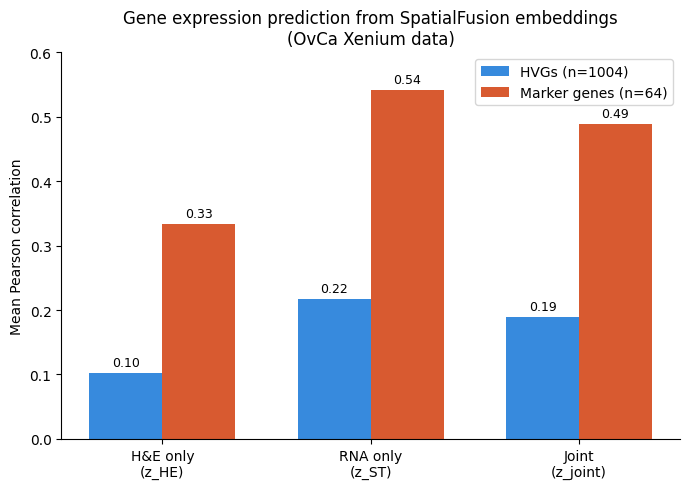

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# labels
embeddings = ["H&E only\n(z_HE)", "RNA only\n(z_ST)", "Joint\n(z_joint)"]

hvgs_pcc    = [0.1019, 0.2171, 0.1895]
markers_pcc = [0.3331, 0.5415, 0.4885]

# --- plotting ---
x = np.arange(len(embeddings))  # [0, 1, 2]
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))

bars1 = ax.bar(x - width/2, hvgs_pcc,    width, label="HVGs (n=1004)",       color="#378ADD")
bars2 = ax.bar(x + width/2, markers_pcc, width, label="Marker genes (n=64)", color="#D85A30")

# labels and styling
ax.set_ylabel("Mean Pearson correlation")
ax.set_title("Gene expression prediction from SpatialFusion embeddings\n(OvCa Xenium data)")
ax.set_xticks(x)
ax.set_xticklabels(embeddings)
ax.set_ylim(0, 0.6)
ax.legend()

# add value labels on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.2f}",
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha="center", va="bottom", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("pearson_correlation_results.png", dpi=200, bbox_inches="tight")
plt.show()

In [2]:
# importing adata for true gexp and cell labels
adata_path = "/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/data/tutadata_subset.h5ad"
adata = sc.read_h5ad(adata_path)

Plotting the top markers and then the predicted markers

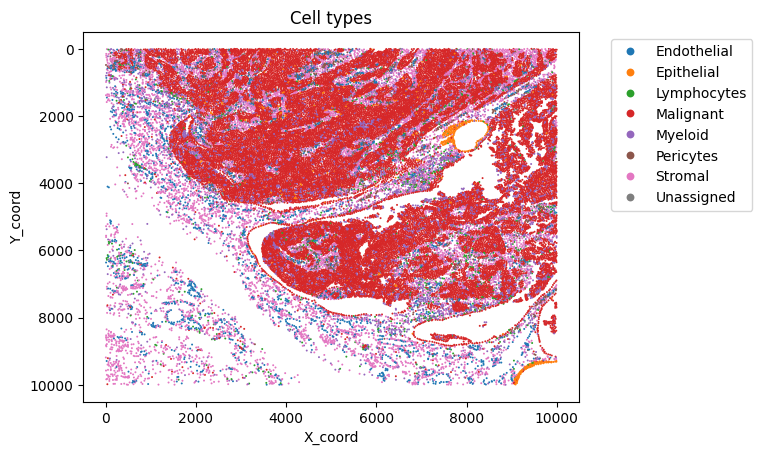

In [ ]:
import seaborn as sns

# importing adata for true gexp and cell labels
adata_path = "/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/data/tutadata_subset.h5ad"
adata = sc.read_h5ad(adata_path)

# read in wsi image (for visualization later)
source_image_path = '/insomnia001/depts/morpheus/users/me2982/data/xenium_ovca_tutorial/data/wsi_crop.ome.tif'
with tifffile.TiffFile(source_image_path) as tif:
    wsi = tif.series[0].asarray()

# Cell types
fig = sns.scatterplot(
    data=adata.obs,
    x='X_coord', y='Y_coord',
    hue='major_celltype',
    palette='tab10',
    s=2,
    linewidth=0
)

fig.invert_yaxis()
fig.set_title("Cell types")
fig.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    scatterpoints=1,
    markerscale=4
)